# Day 019 · 风险中性概率
**Risk-Neutral Probability** · 阶段 P1 · 量化基础

> 风险中性概率是衍生品定价里最反直觉的概念之一。它不是「股票真的会按这个概率涨跌」,而是「我假设有这么一个概率,在这个假设下做估值,得到的价格唯一且无套利」。这一节用一颗最小的二叉树彻底讲清楚:为什么定价要换测度、Q 测度长什么样、跟真实测度 P 差在哪、为什么这一换测度让 BS 公式里的漂移项 μ 神奇地变成无风险利率 r。然后我们把二叉树步数从 N=10 推到 N=1000,看它怎么连续逼近 BS 公式,这是 Cox-Ross-Rubinstein 二叉树模型的精髓。理解这一步你才真懂为什么 BS 公式里出现的是 r 而不是市场预期收益,以及为什么衍生品的「定价」和「期望收益」是两件不同的事。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解为什么衍生品定价不能用真实概率(否则不同人持不同观点 → 不同价 → 套利)
- 推导单步二叉树的风险中性概率公式 q = (e^(rT) - d) / (u - d)
- 用 q 给一份欧式 call 定价,并对照「错误地用真实概率 p」会给出什么价
- 把二叉树步数从 10 推到 1000,看 Cox-Ross-Rubinstein 二叉树连续逼近 BS 公式
- 明白「换测度」的金融直觉 — Girsanov 定理的本质就是把漂移项 μ 替换成 r

## 历史背景:Cox-Ross-Rubinstein 1979 — 二叉树模型怎么诞生的

一九七三年 Black-Scholes-Merton 公式问世,但 BS 公式背后的数学(伊藤引理 + 偏微分方程 + Girsanov 测度变换)对一九七零年代多数从业人员来说太难。Black 自己也说过「我们的公式只有几个搞数学的人能直接用」。

直到一九七九年,三位经济学家 John Cox、Stephen Ross、Mark Rubinstein 在《Journal of Financial Economics》发表了《Option Pricing: A Simplified Approach》— 他们提出**二叉树模型**,把连续时间的 GBM 替换成离散的「每步要么涨 u 要么跌 d」二叉过程。最关键的洞察是:在这个简化的世界里,风险中性概率 q 可以**用初等代数推出来** — 不需要伊藤引理、不需要 PDE,任何会基础概率的人都能推。

CRR 二叉树有三个划时代的影响:
1. **教学**:让风险中性测度变成可以白板讲明白的概念,从此 MBA 课本期权定价都从二叉树开始
2. **数值方法**:对没有解析解的奇异期权(美式期权、回望期权、障碍期权),二叉树是第一个普及的数值方法
3. **理论框架**:CRR 证明了二叉树步数 N → ∞ 时连续逼近 BS 公式,这建立了离散和连续之间的桥梁

今天华尔街交易系统多数用 PDE 有限差分或者 Monte Carlo,但二叉树仍是教学和快速验证的标准。本课就用最小的 N=1 二叉树讲清风险中性概率从哪里来,再把 N 推到 1000 看它逼近 BS。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 为什么衍生品定价不能用真实概率 — 套利论证

**反例**:假设股票今天 100,一年后要么 110(u=1.10) 要么 95(d=0.95),你认为真实涨概率 p = 60%。无风险利率 r = 3%。一份行权价 K=100 的 call payoff 是 max(S-K, 0):上涨 10 / 下跌 0。

**错误做法**:用真实概率算期望 payoff = 0.6 × 10 + 0.4 × 0 = 6,贴现 6 × e^(-0.03) ≈ 5.82,call 价 5.82?

**这个价错了 — 套利者会立刻发动攻击**。原因是:你和我对 p 的看法可能不同。我可能认为 p = 70%,你认为 p = 50%,我们给同一份 call 算出不同价 — 那哪个对?

**金融的答案是**:**两个都错。正确的价跟 p 无关**。无套利原理告诉我们:任何衍生品的价格只取决于「能否被标的资产 + 现金组合复制」,而复制成本是唯一确定的。

复制方法(Δ 对冲):构造一个组合 = Δ 股股票 + B 元现金,使得这个组合在两种情况下的终值都等于期权 payoff。解 Δ 和 B 后,**复制成本 = 期权价**。这个价跟 p 完全无关。

这就是「风险中性概率 q」的来源 — q 是把这个复制论证翻译成概率语言后,凑出来让期望计算与复制结果相同的那个数。q 不是真实概率,是「无套利价的等价表达」。

```
无套利原理:期权价 = 复制组合成本 = E^Q[payoff] × e^(-rT)   //   q 跟真实概率 p 无关
```

> **举例:** 你和我对 p 看法不同,但我们都同意:用 Δ = 10/15 ≈ 0.667 股股票 + 借点钱可以完美复制这份 call。我们算复制成本得到唯一的价。这个价对 p 完全不敏感 — 这就是金融最美的对冲论证。


### 2. 风险中性概率 q 的推导 — 让期望收益等于 r

**核心公式**(单步二叉树):

**q = (e^(rT) - d) / (u - d)**

推导只用一行代数。我们要找 q 使得 E^Q[S_1 / S_0] = e^(rT)(也就是「在 q 测度下股票期望收益等于无风险利率 r」)。展开:

q × u + (1-q) × d = e^(rT)
q u + d - q d = e^(rT)
q (u - d) = e^(rT) - d
**q = (e^(rT) - d) / (u - d)** ✓

这个 q 必须满足 0 < q < 1 才有意义(否则无套利不成立),这要求 d < e^(rT) < u — 简单说:**无风险利率必须夹在「下跌」和「上涨」之间**。如果 e^(rT) > u(无风险利率高过最好情况),你应该全部存银行;如果 e^(rT) < d(无风险利率低于最坏情况),股票稳赚 → 套利。

**记忆口诀**:q 是「让股票变成假装无风险的概率」。在 q 下股票 e^(rT) 增长,贴现回今天就是当前价。这就是为什么衍生品 BS 公式里漂移项是 r 而不是真实预期 μ — 因为我们在 q 测度下计算。

```
q = (e^(rT) - d) / (u - d)   //   要求 d < e^(rT) < u(无套利条件)
```

> **举例:** S=100, u=1.10, d=0.95, r=3%。e^(0.03) ≈ 1.0305。q = (1.0305 - 0.95) / (1.10 - 0.95) = 0.0805 / 0.15 ≈ 0.537。所以风险中性下「上涨概率 53.7%」 — 跟真实概率 60% 差 6 个百分点,这个差就是风险溢价。


### 3. Q 测度 vs P 测度 — 测度变换的金融直觉

**P 测度(真实测度)**:你观察到的股票涨跌频率,反映**真实概率分布**。在 P 下股票期望年化收益 = μ,通常高于 r(因为股票有风险,要给溢价)。

**Q 测度(风险中性测度)**:数学构造,反映**定价时的等价概率**。在 Q 下所有资产期望收益都等于 r,无风险溢价。

两者关系:Q = P × (e^(-(μ-r)T) × ...) 是 Radon-Nikodym 导数,具体公式由 Girsanov 定理给出。

**核心思想 — Girsanov 定理直观版**:换 Q 测度等于把 GBM 的漂移项 μ 替换成 r。微分方程从

dS = μ S dt + σ S dW^P

变成

dS = r S dt + σ S dW^Q

波动率 σ 不变(这是 Girsanov 的关键),漂移变了。所以 BS 公式里出现 r 不是「股票真的只长 r」 — 是「在定价用的 Q 测度下股票长 r」。

**重要区分**:
- 算「股票预期收益」 → 用 P 测度,μ
- 算「衍生品价格」 → 用 Q 测度,r
- 算 VaR / 风险 → 用 P 测度(看真实尾部)
- 算期权对冲成本 → 用 Q 测度

```
P 测度: dS = μ S dt + σ S dW^P  (真实)   //   Q 测度: dS = r S dt + σ S dW^Q  (定价)
```

> **举例:** 你看股票今年涨了 15%(P 测度下的实际)。你买一份这只股票的一年期 ATM call,BS 公式给你的价用的是 r ≈ 3%(Q 测度)。这两个数字看起来不一致 — 但它们做的是不同的工作。P 帮你预测,Q 帮你定价。


### 4. 二叉树的多步推广 — Cox-Ross-Rubinstein 收敛到 BS

**单步二叉树是教学工具**,实战要多步。N 步 CRR 二叉树:

- u = e^(σ √(T/N)),d = 1/u(对称选择)
- q = (e^(rT/N) - d) / (u - d)
- 定价:从最后一层 payoff 倒推,每个节点 V = e^(-r dt) × (q V_up + (1-q) V_down)

**重要定理**(CRR 1979):**当 N → ∞,N 步二叉树价格收敛到 BS 解析价**。

收敛速度大约 O(1/N) — N=10 误差几个百分点,N=100 已经接近 BS,N=1000 基本不可分辨。本课实测会画 N=5 到 N=1000 的二叉树价 vs BS 解析价,你会看到一条波动渐小的曲线收敛到水平 BS 价。

**为什么二叉树仍然有用**(没被 BS 完全取代):
1. **美式期权** — 美式 call/put 可以提前行权,BS 没有解析解,二叉树倒推时每个节点检查「立即行权 vs 继续持有」很自然
2. **奇异期权** — 路径依赖期权(亚式、回望)二叉树需要扩展状态空间,但思路清晰
3. **教学** — N=1 二叉树是讲清楚 q 概念的最佳工具,本课就这么做

**数值方法对比**:
- 二叉树 — 适合美式 / 奇异 / 教学,N=1000 内速度快
- 蒙特卡洛(Day 17 学过)— 适合多资产 / 路径依赖,但对美式不友好(LSM 算法是修正版)
- PDE 有限差分 — 工业标准,精度高但代码复杂

```
CRR 选择: u = e^(σ √(T/N)), d = 1/u, q = (e^(rT/N) - d) / (u - d)   //   N → ∞ 时 价格 → BS
```

> **举例:** ATM call,S=100, K=100, r=3%, σ=25%, T=1y。BS 解析价 ≈ 11.07。N=10 二叉树价 ≈ 11.13(误差 +0.06);N=50 ≈ 11.05(误差 -0.02);N=200 ≈ 11.06(误差 -0.01);N=1000 ≈ 11.07(误差 < 0.01)。收敛速度直观体现 CRR 1979 的定理。


### 5. Q 测度的实战意义 — 校准、对冲、波动率微笑

Q 测度不只是教学工具,实战也用:

**1. 模型校准**
做市商每天看市场期权报价,用这些价格反解 implied volatility 曲面 — 这是「市场认为的 σ」(在 Q 测度下)。如果你的模型给出的价跟 implied vol 不匹配,要么模型错了,要么市场错了(通常是模型)。

**2. Δ 对冲**
Δ = ∂C/∂S 是用 Q 测度算出来的。所以做市商对冲是「Q 测度下的对冲」 — 跟你对市场的预测无关,只跟当前价 / 波动率 / 利率 / 行权价 / 时间有关。

**3. 波动率微笑**(volatility smile / skew)
BS 假设 σ 常数,实际市场 implied vol 随行权价变化(深 OTM put 比 ATM 高 5-10 vol),这就是「微笑」。微笑反映市场认为下跌尾部更厚 — 也就是 Q 测度认知的尾部跟正态不符。这是 GBM / BS 模型在尾部失效的市场表达。

**4. 风险中性密度**
从期权价格曲线对 K 求二阶导,可以反推 S_T 在 Q 测度下的概率密度(Breeden-Litzenberger 公式)。这是市场告诉你它对未来分布的认知。专业用法 — 跟踪市场情绪 / 风险偏好。

**记住一条**:Q 测度是「定价语言」,P 测度是「预测语言」。两者不冲突,各司其职。

```
Δ_BS = N(d_1)  //  Implied Vol = inv-BS(market_price)  //  Q-density = ∂²C/∂K²
```

> **举例:** 2008 金融危机后 SPX 期权深 OTM put 的 implied vol 比 ATM 高 15-20 vol — 市场在 Q 测度下定价「极端下跌」。你做尾部风险对冲,买这种 put 比 BS 公式给的「公允价」贵很多 — 但贵得有道理,因为市场认为厚尾真实存在。


## 实操:二叉树推导风险中性概率 + Q 定价 vs P 定价 + N 步二叉树收敛 BS

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


=== 单步二叉树:风险中性概率 q 推导 ===
参数: S=100.0 / u=1.1 / d=0.95 / r=3%
风险中性概率 q = (e^(rT) - d) / (u - d) = (1.0305 - 0.95) / (1.1 - 0.95) = 0.5364
所以 q ≈ 0.5364, 1-q ≈ 0.4636
验证: q × u + (1-q) × d = 1.0305 = exp(rT) = 1.0305 ✓

=== 真实测度 P vs 风险中性测度 Q ===
真实概率 p = 60%, 期望年化收益 = 4.00%(高于 r=3%,反映风险溢价)
风险中性 q = 0.5364, 期望年化收益 = 3.05%(等于 r,无风险溢价)
风险溢价 = 1.00%(P 测度下股票多赚的部分)

=== 用 q 给欧式 call 定价 ===
行权价 K = 100.0
上涨 payoff = max(110.00000000000001 - 100.0, 0) = 10.000000000000014
下跌 payoff = max(95.0 - 100.0, 0) = 0
风险中性期望 payoff = q × 10.000000000000014 + (1-q) × 0 = 5.3636
贴现到今天: call 价 = 5.3636 × exp(-rT) = 5.2051

如果用真实概率 p 定价(错误做法):
真实期望 payoff = p × 10.000000000000014 + (1-p) × 0 = 6.0000
贴现 = 5.8227  ← 比 q 定价高,因为真实概率反映了风险溢价
结论:衍生品定价必须用 q,否则套利机会立刻出现

=== 多步二叉树 → BS 收敛(S=100, K=100, r=3%, σ=25%, T=1)===
      步数 N          二叉树价格         BS 解析价           误差
        10        11.1052        11.3485      -0.2433
        50        11.2993        11.3485      -0.0492
       200        11.3361        1

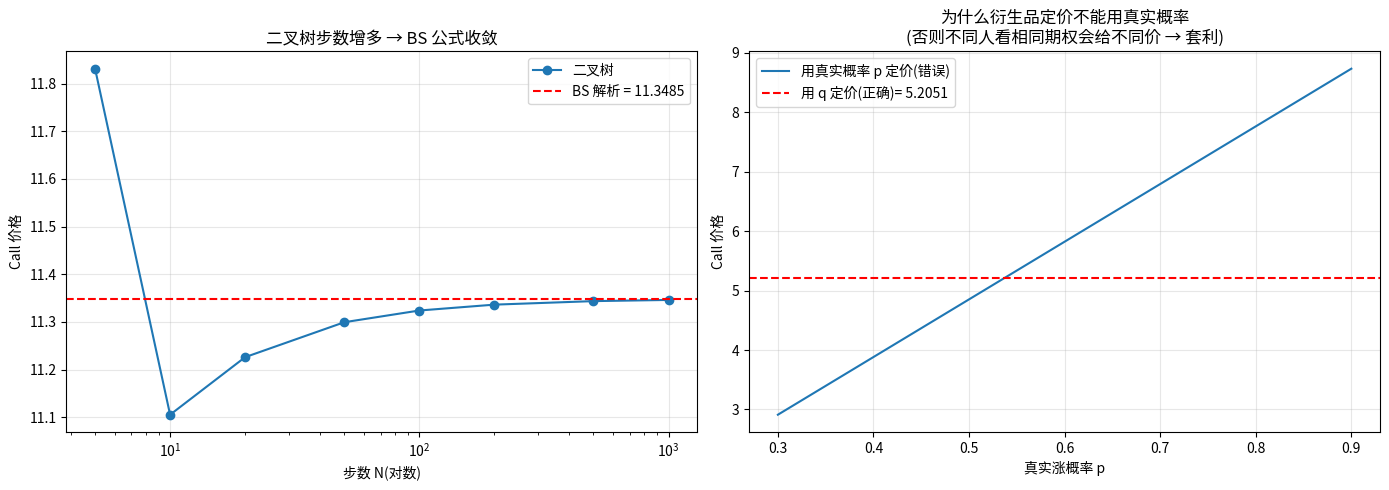

In [2]:
# day_019_risk_neutral.py — 风险中性测度:从二叉树到 GBM 框架
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# ============ 1. 单步二叉树:风险中性概率 q 的推导 ============
# 当前股价 S = 100,一步后涨到 uS = 110(u=1.10) 或 跌到 dS = 95(d=0.95)
# 无风险利率 r = 3% / 年,一步 = 1 年
S = 100.0
u, d = 1.10, 0.95
r = 0.03
T_step = 1.0

# 风险中性概率 q 让「期望收益 = 无风险利率」
# E^Q[S_1] / S = exp(r T)  ⟹  q × u + (1-q) × d = exp(r T)
# ⟹ q = (exp(r T) - d) / (u - d)
q = (np.exp(r * T_step) - d) / (u - d)
print('=== 单步二叉树:风险中性概率 q 推导 ===')
print(f'参数: S={S} / u={u} / d={d} / r={r:.0%}')
print(f'风险中性概率 q = (e^(rT) - d) / (u - d) = ({np.exp(r*T_step):.4f} - {d}) / ({u} - {d}) = {q:.4f}')
print(f'所以 q ≈ {q:.4f}, 1-q ≈ {1-q:.4f}')
print(f'验证: q × u + (1-q) × d = {q*u + (1-q)*d:.4f} = exp(rT) = {np.exp(r*T_step):.4f} ✓')

# ============ 2. 真实概率 p vs 风险中性概率 q 对比 ============
# 假设真实涨概率 p = 60%(股票期望收益高于 r,因为有风险溢价)
p = 0.60
real_expected_return = (p * u + (1-p) * d) - 1
print('\n=== 真实测度 P vs 风险中性测度 Q ===')
print(f'真实概率 p = {p:.0%}, 期望年化收益 = {real_expected_return:.2%}(高于 r={r:.0%},反映风险溢价)')
print(f'风险中性 q = {q:.4f}, 期望年化收益 = {q*u + (1-q)*d - 1:.2%}(等于 r,无风险溢价)')
print(f'风险溢价 = {real_expected_return - r:.2%}(P 测度下股票多赚的部分)')

# ============ 3. 用风险中性概率给一份欧式 call 定价 ============
# 行权价 K = 100,一步后期权 payoff = max(S_1 - K, 0)
K = 100.0
payoff_up = max(S * u - K, 0)
payoff_dn = max(S * d - K, 0)
print('\n=== 用 q 给欧式 call 定价 ===')
print(f'行权价 K = {K}')
print(f'上涨 payoff = max({S*u} - {K}, 0) = {payoff_up}')
print(f'下跌 payoff = max({S*d} - {K}, 0) = {payoff_dn}')
expected_payoff_Q = q * payoff_up + (1-q) * payoff_dn
call_price = expected_payoff_Q * np.exp(-r * T_step)
print(f'风险中性期望 payoff = q × {payoff_up} + (1-q) × {payoff_dn} = {expected_payoff_Q:.4f}')
print(f'贴现到今天: call 价 = {expected_payoff_Q:.4f} × exp(-rT) = {call_price:.4f}')

# ============ 4. 用真实概率定价(错误!)对比 ============
expected_payoff_P = p * payoff_up + (1-p) * payoff_dn
wrong_call_price = expected_payoff_P * np.exp(-r * T_step)
print(f'\n如果用真实概率 p 定价(错误做法):')
print(f'真实期望 payoff = p × {payoff_up} + (1-p) × {payoff_dn} = {expected_payoff_P:.4f}')
print(f'贴现 = {wrong_call_price:.4f}  ← 比 q 定价高,因为真实概率反映了风险溢价')
print('结论:衍生品定价必须用 q,否则套利机会立刻出现')

# ============ 5. 多步二叉树趋近 BS 公式(N=10/50/200/1000)============
from math import comb
def binomial_call(S, K, r, sigma, T, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1.0 / u
    q = (np.exp(r * dt) - d) / (u - d)
    price = 0.0
    for j in range(N + 1):
        S_T = S * (u ** j) * (d ** (N - j))
        payoff = max(S_T - K, 0)
        prob = comb(N, j) * (q ** j) * ((1 - q) ** (N - j))
        price += prob * payoff
    return price * np.exp(-r * T)

from scipy.stats import norm
def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

S, K, r, sigma, T = 100.0, 100.0, 0.03, 0.25, 1.0
bs_price = bs_call(S, K, r, sigma, T)
print('\n=== 多步二叉树 → BS 收敛(S=100, K=100, r=3%, σ=25%, T=1)===')
print(f'{"步数 N":>10s} {"二叉树价格":>14s} {"BS 解析价":>14s} {"误差":>12s}')
for N in [10, 50, 200, 1000]:
    bp = binomial_call(S, K, r, sigma, T, N)
    err = bp - bs_price
    print(f'{N:>10d} {bp:>14.4f} {bs_price:>14.4f} {err:>12.4f}')

# ============ 6. 画图 ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
Ns = [5, 10, 20, 50, 100, 200, 500, 1000]
binom_prices = [binomial_call(S, K, r, sigma, T, N) for N in Ns]
ax.plot(Ns, binom_prices, 'o-', label='二叉树')
ax.axhline(bs_price, color='red', linestyle='--', label=f'BS 解析 = {bs_price:.4f}')
ax.set_xscale('log')
ax.set_xlabel('步数 N(对数)'); ax.set_ylabel('Call 价格')
ax.set_title('二叉树步数增多 → BS 公式收敛'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ps = np.linspace(0.3, 0.9, 30)
real_prices = [(p_ * payoff_up + (1-p_) * payoff_dn) * np.exp(-r*T_step) for p_ in ps]
ax.plot(ps, real_prices, label='用真实概率 p 定价(错误)')
ax.axhline(call_price, color='red', linestyle='--', label=f'用 q 定价(正确)= {call_price:.4f}')
ax.set_xlabel('真实涨概率 p'); ax.set_ylabel('Call 价格')
ax.set_title('为什么衍生品定价不能用真实概率\n(否则不同人看相同期权会给不同价 → 套利)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('day019_risk_neutral.png', dpi=150, bbox_inches='tight')
print('\n✓ 图已保存到 day019_risk_neutral.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1973 BSM 公式 | Black-Scholes-Merton | Fischer Black、Myron Scholes、Robert Merton 三人独立推出风险中性测度下的期权定价 — 公式里的漂移项是 r 而不是市场预期 μ,这个看似神秘的现象在 Q 测度下立即解释。论文当年被多家期刊拒,直到一九七三年发表后立刻席卷华尔街。 |
| 1979 CRR 二叉树 | Cox-Ross-Rubinstein | 三位经济学家用初等代数推出风险中性概率 q,把 BS 公式简化成所有人能看懂的二叉树。这一篇论文让风险中性测度从博士级数学变成 MBA 教材内容,催生整整一代金融实务者。 |
| 1990s 华尔街 Δ 对冲 | Goldman Sachs / Morgan Stanley | 投行做市商每天给客户报期权价,用 Q 测度计算 Δ 然后买卖标的对冲。一九九零年代发现实际市价偏离 BS 公式,加入 implied vol surface 修正 — 这是 Q 测度从理论到实战的关键升级。 |
| 2008 金融危机后 | SPX 期权 | 金融危机后 SPX 深 OTM put 的 implied vol 比 ATM 高 15-20 vol,市场在 Q 测度下定价极端下跌风险。这个「波动率微笑」是 GBM / BS 假设的真实分布跟市场分布偏离的直接表达。 |
| 美式期权 vs 欧式期权 | 苹果美式 put | 苹果美式 put 因为可以提前行权,价格略高于欧式同条件 put。BS 公式给不出美式价,业界用二叉树 / PDE / LSM 蒙特卡洛三种方法。Q 测度在每种方法里都是核心,只是技术实现不同。 |


## 常见坑

### ⚠ 01. 把 Q 测度的 r 当成股票真实预期收益

BS 公式里漂移项是 r,不代表股票真的只长 r。这只是 Q 测度下的代数。**算预期收益用 P 测度的 μ,算定价用 Q 测度的 r,二者各司其职**。混淆这两个会得出「股票就长 r」的错误结论。

### ⚠ 02. 用真实概率 p 给衍生品定价

无套利论证证明了:衍生品定价跟 p 无关,只跟标的复制成本有关。任何用 p 算的衍生品价都是错的(除非碰巧 p = q)。这是金融最反直觉的结论之一,但也是最稳健的。

### ⚠ 03. 忘记验证 0 < q < 1 的无套利条件

q = (e^(rT) - d) / (u - d) 要求 d < e^(rT) < u。如果违反,意味着市场存在无风险套利 — 你的参数(u/d/r)选错了。**写代码先 assert 这个条件,否则 q 出 -0.5 / 1.3 等无意义值**。

### ⚠ 04. 二叉树步数 N 太小就敢报「BS 收敛」

N=10 二叉树跟 BS 解析价误差几个百分点,N=50 还有锯齿,N=200 才平滑收敛。**画收敛曲线 N 取 5/10/20/50/100/200/500/1000 八档**,看出锯齿衰减后才能说「证明了收敛」。N=20 给 BS 收敛证明的人是不严谨。

### ⚠ 05. 把波动率微笑当成模型参数

波动率微笑是 BS 模型不完美的市场表达,不是 BS 的「参数」。看到不同行权价 implied vol 不一样别套用「平均 σ」 — 要么用模型(SABR / Heston)直接拟合微笑曲线,要么对每份期权单独估值。混合 implied vol 跑回测会得出错误结论。

## 实战 SOP · 风险中性概率实战 SOP

1. **算预期 / 风险用 P 测度,算价格 / 对冲用 Q 测度** — 永远分清你在干什么
2. 二叉树定价代码先 assert 0 < q < 1 然后再算,不验证视为有 bug
3. 二叉树证明 BS 收敛要画 N=5 到 N=1000 八档曲线,N=20 不能算「证明」
4. **implied volatility surface 是市场的 Q 测度认知**,做市商每天看,直接体现在期权报价
5. Δ 对冲用 Q 测度参数(N(d_1)),不要用 P 测度数据 — 否则对冲精度大幅下降
6. 美式期权必须用二叉树 / PDE,BS 公式给不出 — 提前行权决策每个节点都要检查
7. 记住 Girsanov 直觉:换测度只改漂移不改波动率,σ 在 P 和 Q 下相同

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 自测题

**Q1.** 为什么衍生品定价不能用真实概率 p?具体说一个反例:如果你和我对 p 看法不同,会出什么问题?

**Q2.** 推导单步二叉树 q 公式 q = (e^(rT) - d) / (u - d),并说明 q 的金融含义。

**Q3.** S=100, u=1.10, d=0.95, r=3%, T=1, K=100, 算这份 call 的 q 测度价,以及如果错误用 p=60% 真实概率给的价,二者差多少?

**Q4.** 为什么 BS 公式里漂移项是 r 而不是市场预期 μ?用 Girsanov 定理的直觉解释。

**Q5.** 二叉树步数从 N=10 推到 N=1000 要怎么调 u 和 d?Cox-Ross-Rubinstein 模型如何选择?为什么 N → ∞ 时收敛到 BS?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 020 · Black-Scholes 直觉** (BS Intuition)

下一节(D20 Black-Scholes 直觉)用今天推完的 q 测度 + GBM 把 BS 公式从 Δ 对冲组合的角度直接推出来。我们不走 PDE / Girsanov 数学,而是用最少的代数让你看明白 BS 公式里 N(d_1) 和 N(d_2) 各代表什么、为什么 d_1 - d_2 = σ √T、为什么 ATM call 的 BS 价大约等于 0.4 × σ × √T × S。然后用 scipy 算几个真实标的的 BS 价,跟期权链市价对比看 implied vol 怎么反推出来,这是从「BS 是公式」走到「BS 是工具」的关键一步。

## 推荐阅读

- Cox, Ross, Rubinstein《Option Pricing: A Simplified Approach》(JFE 一九七九)— 二叉树模型奠基,把风险中性测度从博士数学变成本科教材
- Hull《Options, Futures, and Other Derivatives》(11 版,十三 / 十四章)— 二叉树和风险中性测度的完整推导,衍生品教科书圣经
- Black, Scholes, Merton 三篇 1973 年原始论文 — 风险中性测度在 PDE 视角下的诞生,数学难但是金融工程的源头
- Taleb《Dynamic Hedging》(一九九七)— 实务派批 BS / Q 测度局限,从交易员视角看模型误差和波动率微笑,实战必读
- scipy.stats.norm.cdf + scipy.optimize.brentq — Python 算 BS 价格 + implied volatility 反解,本课和 Day 20 用到的最简工具